# Evaluación del modelo de clustering — FPA Latam
## Notebook `05_evaluation/01_evaluacion_clustering.ipynb`

Este notebook valida el modelo de clustering construido en `04_modeling/01_clustering.ipynb`.  
**No re-entrena modelos**; opera exclusivamente sobre los artefactos exportados en `04_modeling/outputs/`.

| Parámetro | Valor |
|---|---|
| Capa 1 — fuente | SRI (variables firmográficas) |
| Capa 1 — empresas | N = 163 (post-deduplicación) |
| Capa 1 — K elegido | K = 4 |
| Capa 2 — fuente | SRI + ranking SCVS |
| Capa 2 — empresas | N = 92 |
| Capa 2 — K elegido | K = 2 |
| Clientes FPA Capa 1 | 49 / 163 = 30,1 % |
| Clientes FPA Capa 2 | 36 / 92 = 39,1 % |

## 1. Importación de librerías y configuración de rutas

In [28]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, adjusted_rand_score
)

# ── Rutas ──────────────────────────────────────────────────────────────────────
ROOT        = Path(r"E:\TESIS MAESTRIA\Desarrollo_clustering_maestria")
FE_OUT      = ROOT / "03_feature_engineering" / "outputs"
MOD_OUT     = ROOT / "04_modeling" / "outputs"
EVAL_OUT    = ROOT / "05_evaluation" / "outputs"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# ── Estética ───────────────────────────────────────────────────────────────────
PALETTE_C1 = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]   # 4 clusters Capa 1
PALETTE_C2 = ["#2196F3", "#FF5722"]                          # 2 clusters Capa 2
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Librerías cargadas")
print(f"  Outputs modelado : {MOD_OUT}")
print(f"  Outputs evaluación: {EVAL_OUT}")

✓ Librerías cargadas
  Outputs modelado : E:\TESIS MAESTRIA\Desarrollo_clustering_maestria\04_modeling\outputs
  Outputs evaluación: E:\TESIS MAESTRIA\Desarrollo_clustering_maestria\05_evaluation\outputs


## 2. Carga de artefactos del modelo

In [29]:
# ── Matrices de features (para PCA / silhouette recalculado) ──────────────────
# FE exports: matriz_capa1/2.csv contienen SOLO features (sin RUC)
#             labels_capa1/2.csv contienen los metadatos (RUC, es_cliente_fpa, etc.)
matriz_c1_raw   = pd.read_csv(FE_OUT / "matriz_capa1.csv")     # 175 × 15
labels_c1_raw   = pd.read_csv(FE_OUT / "labels_capa1.csv")     # 175 × 5

matriz_c2_raw   = pd.read_csv(FE_OUT / "matriz_capa2.csv")     # 92 × 21
labels_c2_meta  = pd.read_csv(FE_OUT / "labels_capa2.csv")     # 92 × 6
features_c2_raw = pd.read_csv(FE_OUT / "features_capa2.csv")   # 92 × 20 (con RUC + meta)

# Etiquetas de cluster y metadatos del modelo
clusters_c1    = pd.read_csv(MOD_OUT / "clusters_capa1.csv")
clusters_c2    = pd.read_csv(MOD_OUT / "clusters_capa2.csv")
clusters_c2_k4 = pd.read_csv(MOD_OUT / "clusters_capa2_k4_sensibilidad.csv")

# Perfiles y métricas
perfil_c1      = pd.read_csv(MOD_OUT / "perfil_clusters_capa1.csv")
perfil_c2      = pd.read_csv(MOD_OUT / "perfil_clusters_capa2.csv")
perfil_c2_k4   = pd.read_csv(MOD_OUT / "perfil_clusters_capa2_k4.csv")
met_kmeans_c1  = pd.read_csv(MOD_OUT / "metricas_kmeans_capa1.csv")
met_kmeans_c2  = pd.read_csv(MOD_OUT / "metricas_kmeans_capa2.csv")
met_ward_c1    = pd.read_csv(MOD_OUT / "metricas_ward_capa1.csv")
met_ward_c2    = pd.read_csv(MOD_OUT / "metricas_ward_capa2.csv")
cobertura_c1   = pd.read_csv(MOD_OUT / "cobertura_financiera_por_cluster_capa1.csv")
comparacion    = pd.read_csv(MOD_OUT / "comparacion_capas_best_k.csv")
comp_same_k    = pd.read_csv(MOD_OUT / "comparacion_capas_same_k.csv")

# ── Construir matriz escalada de Capa 1 ───────────────────────────────────────
# Combinar matriz (features) con labels (metadatos) — están alineados por índice
df_c1_full = pd.concat([labels_c1_raw, matriz_c1_raw], axis=1)
cols_modelo_c1 = matriz_c1_raw.columns.tolist()

# Deduplicar: conservar max(es_cliente_fpa) por RUC
df_c1_dedup = (
    df_c1_full
    .sort_values("es_cliente_fpa", ascending=False)
    .drop_duplicates(subset="RUC", keep="first")
    .reset_index(drop=True)
)
print(f"Matriz Capa 1: {len(df_c1_dedup)} filas tras deduplicar (original: {len(df_c1_full)})")

# Escalar
scaler_c1   = StandardScaler()
X_c1_scaled = scaler_c1.fit_transform(df_c1_dedup[cols_modelo_c1])

# Etiquetas de cluster — alinear por RUC
labels_c1   = clusters_c1.set_index("RUC").reindex(df_c1_dedup["RUC"])["cluster_capa1"].values
print(f"Labels Capa 1: {np.unique(labels_c1, return_counts=True)}")

# ── Matriz escalada Capa 2 ─────────────────────────────────────────────────────
# Usar features_capa2.csv que contiene el RUC para alineación
rucs_c2     = labels_c2_meta["RUC"].values          # RUCs alineados con matriz_c2_raw
cols_modelo_c2 = matriz_c2_raw.columns.tolist()

scaler_c2   = StandardScaler()
X_c2_scaled = scaler_c2.fit_transform(matriz_c2_raw)
labels_c2   = clusters_c2.set_index("RUC").reindex(rucs_c2)["cluster_capa2"].values
print(f"Matriz Capa 2: {len(matriz_c2_raw)} filas")
print(f"Labels Capa 2: {np.unique(labels_c2, return_counts=True)}")

# ── Verificaciones de integridad ───────────────────────────────────────────────
n_c1_dedup    = len(df_c1_dedup)
n_c2_features = len(features_c2_raw)

assert df_c1_dedup["RUC"].nunique() == n_c1_dedup, "Duplicados en Capa 1"
assert n_c2_features == len(matriz_c2_raw), f"Desajuste filas Capa 2: features={n_c2_features}, matriz={len(matriz_c2_raw)}"

fpa_c1 = clusters_c1["es_cliente_fpa"].sum()
fpa_c2 = clusters_c2["es_cliente_fpa"].sum()
print(f"\n✓ Integridad OK")
print(f"  Capa 1: {n_c1_dedup} filas deduplicadas")
print(f"  Capa 2: {n_c2_features} filas")
print(f"  Clientes FPA Capa 1: {fpa_c1} / {len(clusters_c1)}  = {fpa_c1/len(clusters_c1):.1%}")
print(f"  Clientes FPA Capa 2: {fpa_c2} / {len(clusters_c2)}  = {fpa_c2/len(clusters_c2):.1%}")


Matriz Capa 1: 157 filas tras deduplicar (original: 167)
Labels Capa 1: (array([0, 1, 2, 3]), array([50, 34, 38, 35]))
Matriz Capa 2: 87 filas
Labels Capa 2: (array([0, 1]), array([35, 52]))

✓ Integridad OK
  Capa 1: 157 filas deduplicadas
  Capa 2: 87 filas
  Clientes FPA Capa 1: 51 / 157  = 32.5%
  Clientes FPA Capa 2: 37 / 87  = 42.5%


## 3. Validación interna: Silhouette, Davies-Bouldin e Inercia

In [30]:
# ── Métricas internas recalculadas sobre las asignaciones finales ─────────────
sil_c1  = silhouette_score(X_c1_scaled, labels_c1)
db_c1   = davies_bouldin_score(X_c1_scaled, labels_c1)
sil_c2  = silhouette_score(X_c2_scaled, labels_c2)
db_c2   = davies_bouldin_score(X_c2_scaled, labels_c2)

print("=== Métricas internas (modelo final) ===")
print(f"Capa 1  K=4  Silhouette={sil_c1:.3f}  Davies-Bouldin={db_c1:.3f}")
print(f"Capa 2  K=2  Silhouette={sil_c2:.3f}  Davies-Bouldin={db_c2:.3f}")

# ── Tabla comparativa K vs métricas (KMeans + Ward) ──────────────────────────
print("\n=== Métricas KMeans Capa 1 (por K) ===")
display(met_kmeans_c1.set_index("k").round(3))

print("=== Métricas Ward Capa 1 (por K) ===")
display(met_ward_c1.set_index("k").round(3))

print("=== Métricas KMeans Capa 2 (por K) ===")
display(met_kmeans_c2.set_index("k").round(3))

=== Métricas internas (modelo final) ===
Capa 1  K=4  Silhouette=0.170  Davies-Bouldin=1.853
Capa 2  K=2  Silhouette=0.249  Davies-Bouldin=1.680

=== Métricas KMeans Capa 1 (por K) ===


,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,,
2,386.977,0.266,1.487,55,102
3,328.741,0.223,1.639,39,68
4,297.160,0.213,1.613,34,50
5,273.128,0.193,1.788,25,37
6,252.785,0.196,1.639,20,35
7,240.059,0.192,1.623,18,30
8,229.127,0.186,1.635,13,32


=== Métricas Ward Capa 1 (por K) ===


,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,
2,0.257,1.506,51,106
3,0.189,1.854,43,63
4,0.185,1.731,28,51
5,0.162,1.924,24,43
6,0.164,1.800,16,35


=== Métricas KMeans Capa 2 (por K) ===


,inertia,silhouette,davies_bouldin,min_cluster_size,max_cluster_size
k,,,,,
2,477.748,0.386,1.093,35,52
3,393.460,0.399,0.870,2,52
4,313.026,0.409,0.688,1,50
5,268.114,0.259,1.088,1,33
6,241.137,0.252,1.052,1,41
7,218.272,0.190,1.254,1,23
8,196.158,0.200,1.169,1,21


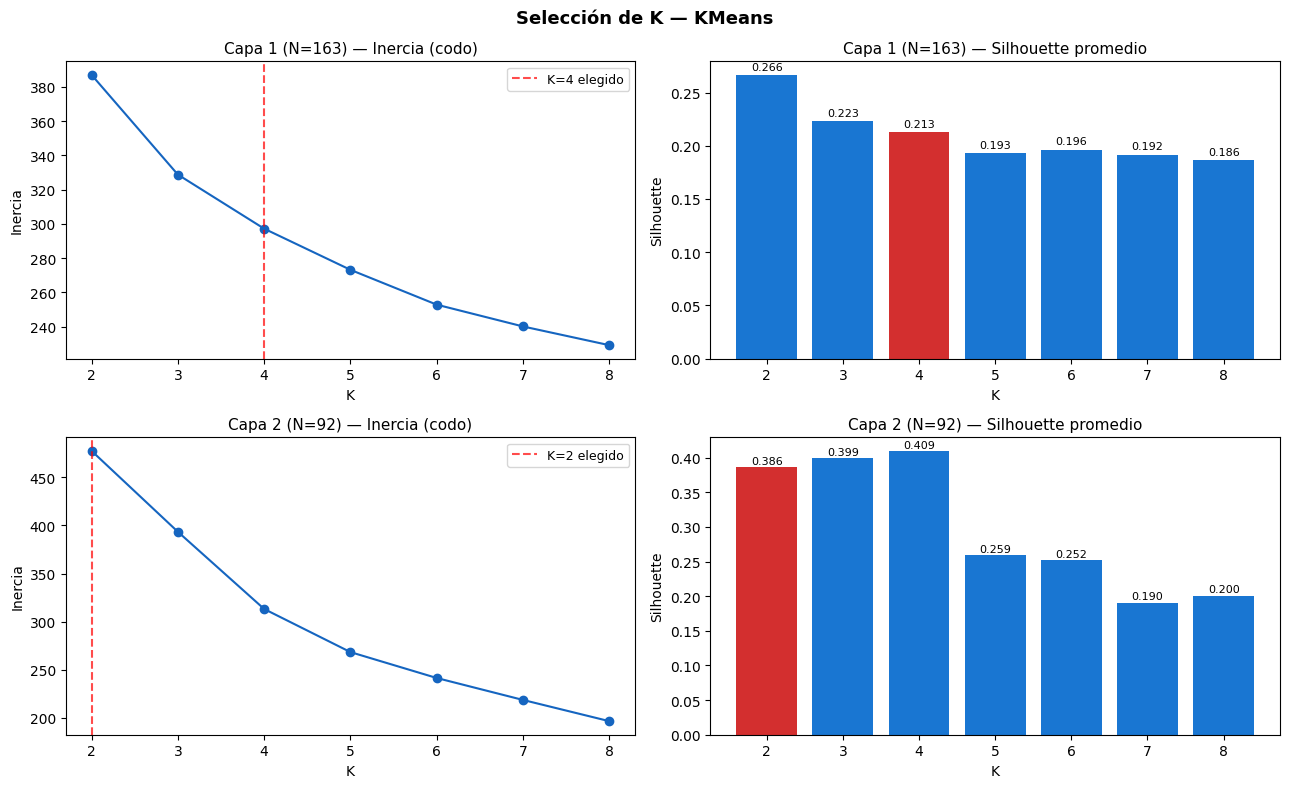

✓ Guardado: fig_seleccion_k_kmeans.png


In [31]:
# ── Curvas de elbow + Silhouette (KMeans, Capa 1 y Capa 2) ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Selección de K — KMeans", fontsize=13, fontweight="bold")

for ax_row, (met, capa, chosen) in enumerate([
    (met_kmeans_c1, "Capa 1 (N=163)", 4),
    (met_kmeans_c2, "Capa 2 (N=92)",  2),
]):
    ax_iner = axes[ax_row, 0]
    ax_sil  = axes[ax_row, 1]

    ax_iner.plot(met["k"], met["inertia"], "o-", color="#1565C0")
    ax_iner.axvline(chosen, color="red", linestyle="--", alpha=0.7, label=f"K={chosen} elegido")
    ax_iner.set_title(f"{capa} — Inercia (codo)", fontsize=11)
    ax_iner.set_xlabel("K"); ax_iner.set_ylabel("Inercia")
    ax_iner.legend(fontsize=9)

    color_sil = ["#D32F2F" if k == chosen else "#1976D2" for k in met["k"]]
    ax_sil.bar(met["k"], met["silhouette"], color=color_sil)
    ax_sil.set_title(f"{capa} — Silhouette promedio", fontsize=11)
    ax_sil.set_xlabel("K"); ax_sil.set_ylabel("Silhouette")
    for k, v in zip(met["k"], met["silhouette"]):
        ax_sil.text(k, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_seleccion_k_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_seleccion_k_kmeans.png")

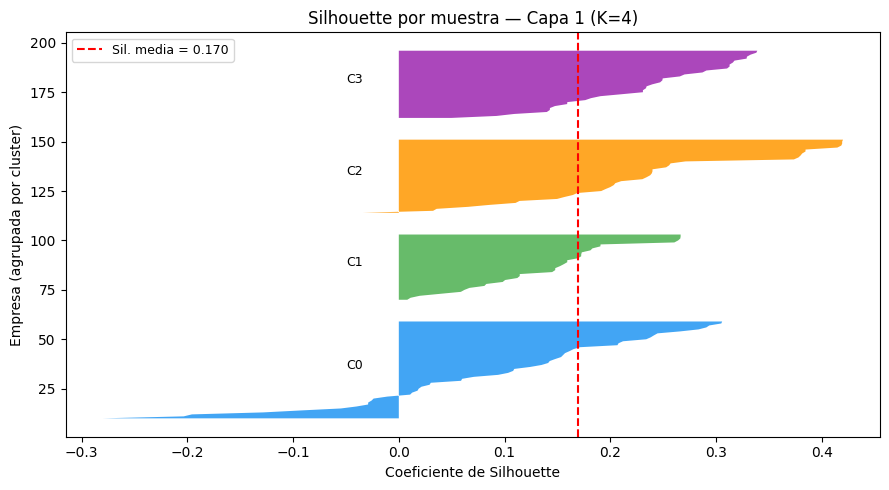

✓ Guardado: fig_silhouette_muestras_c1.png


In [32]:
# ── Gráfico de Silhouette por muestra — Capa 1 K=4 ───────────────────────────
sil_samples_c1 = silhouette_samples(X_c1_scaled, labels_c1)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(4):
    ith_sil = np.sort(sil_samples_c1[labels_c1 == i])
    size_i  = ith_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=PALETTE_C1[i], edgecolor="none", alpha=0.85)
    ax.text(-0.05, y_lower + 0.5 * size_i, f"C{i}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_c1, color="red", linestyle="--", label=f"Sil. media = {sil_c1:.3f}")
ax.set_xlabel("Coeficiente de Silhouette"); ax.set_ylabel("Empresa (agrupada por cluster)")
ax.set_title("Silhouette por muestra — Capa 1 (K=4)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_silhouette_muestras_c1.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Guardado: fig_silhouette_muestras_c1.png")

## 4. Validación externa: tasa de clientes FPA por cluster

In [33]:
# ── Tabla de validación externa FPA — Capa 1 ─────────────────────────────────
TASA_BASE_C1 = 49 / 163

val_c1 = (
    clusters_c1
    .groupby("cluster_capa1")
    .agg(
        segmento=("segmento_capa1", "first"),
        n=("es_cliente_fpa", "count"),
        clientes_fpa=("es_cliente_fpa", "sum"),
    )
    .assign(tasa_clientes=lambda d: d["clientes_fpa"] / d["n"])
    .reset_index()
)
val_c1["vs_base"] = val_c1["tasa_clientes"] - TASA_BASE_C1
print("=== Validación externa — Capa 1 ===")
display(val_c1.round(4))

# ── Chi-cuadrado ──────────────────────────────────────────────────────────────
contingencia_c1 = pd.crosstab(clusters_c1["cluster_capa1"], clusters_c1["es_cliente_fpa"])
chi2_c1, p_c1, dof_c1, _ = chi2_contingency(contingencia_c1)
print(f"\nChi-cuadrado Capa 1: χ²={chi2_c1:.3f}  p={p_c1:.4f}  gl={dof_c1}")
if p_c1 < 0.05:
    print("→ La distribución de clientes FPA difiere significativamente entre clusters (p < 0.05)")
else:
    print("→ No se detecta diferencia significativa (p ≥ 0.05)")

# ── Tabla validación Capa 2 ───────────────────────────────────────────────────
TASA_BASE_C2 = 36 / 92
val_c2 = (
    clusters_c2
    .groupby("cluster_capa2")
    .agg(
        segmento=("segmento_capa2", "first"),
        n=("es_cliente_fpa", "count"),
        clientes_fpa=("es_cliente_fpa", "sum"),
    )
    .assign(tasa_clientes=lambda d: d["clientes_fpa"] / d["n"])
    .reset_index()
)
val_c2["vs_base"] = val_c2["tasa_clientes"] - TASA_BASE_C2
print("\n=== Validación externa — Capa 2 ===")
display(val_c2.round(4))

contingencia_c2 = pd.crosstab(clusters_c2["cluster_capa2"], clusters_c2["es_cliente_fpa"])
chi2_c2, p_c2, dof_c2, _ = chi2_contingency(contingencia_c2)
print(f"\nChi-cuadrado Capa 2: χ²={chi2_c2:.3f}  p={p_c2:.4f}  gl={dof_c2}")

=== Validación externa — Capa 1 ===


,cluster_capa1,segmento,n,clientes_fpa,tasa_clientes,vs_base
0,0,Sociedades jovenes de alta afinidad FPA,50,24,0.4800,0.1794
1,1,Grandes corporativos maduros establecidos,34,17,0.5000,0.1994
2,2,Empresas comerciales de Guayas,38,4,0.1053,-0.1954
3,3,Personas naturales del resto del pais,35,6,0.1714,-0.1292



Chi-cuadrado Capa 1: χ²=22.354  p=0.0001  gl=3
→ La distribución de clientes FPA difiere significativamente entre clusters (p < 0.05)

=== Validación externa — Capa 2 ===


,cluster_capa2,segmento,n,clientes_fpa,tasa_clientes,vs_base
0,0,Empresas pequenas y recientes,35,15,0.4286,0.0373
1,1,Empresas medianas-grandes consolidadas,52,22,0.4231,0.0318



Chi-cuadrado Capa 2: χ²=0.000  p=1.0000  gl=1


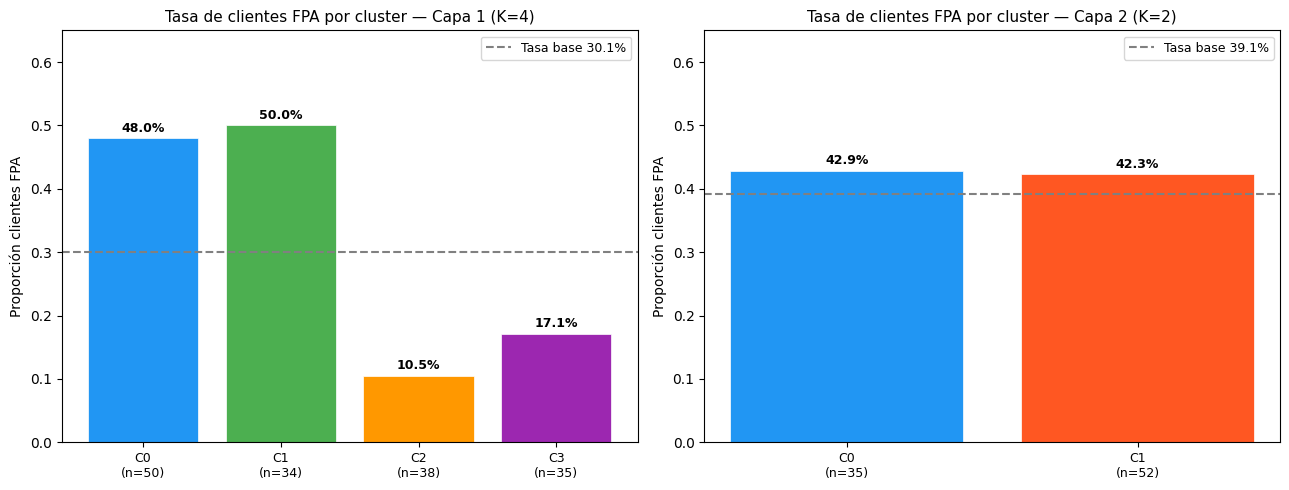

✓ Guardado: fig_tasa_fpa_por_cluster.png


In [34]:
# ── Gráfico: Tasa FPA por cluster — Capa 1 y Capa 2 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, val_df, palette, base, capa, k in [
    (axes[0], val_c1, PALETTE_C1, TASA_BASE_C1, "Capa 1 (K=4)", 4),
    (axes[1], val_c2, PALETTE_C2, TASA_BASE_C2, "Capa 2 (K=2)", 2),
]:
    bars = ax.bar(val_df.index, val_df["tasa_clientes"],
                  color=palette[:k], edgecolor="white", linewidth=0.5)
    ax.axhline(base, color="gray", linestyle="--", linewidth=1.5, label=f"Tasa base {base:.1%}")
    ax.set_xticks(val_df.index)
    ax.set_xticklabels([f"C{c}\n(n={n})" for c, n in zip(val_df.iloc[:, 0], val_df["n"])],
                       fontsize=9)
    ax.set_ylabel("Proporción clientes FPA")
    ax.set_title(f"Tasa de clientes FPA por cluster — {capa}", fontsize=11)
    ax.set_ylim(0, 0.65)
    for bar, tasa in zip(bars, val_df["tasa_clientes"]):
        ax.text(bar.get_x() + bar.get_width() / 2, tasa + 0.01,
                f"{tasa:.1%}", ha="center", fontsize=9, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_tasa_fpa_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_tasa_fpa_por_cluster.png")

## 5. Análisis de concordancia entre capas (ARI)

In [35]:
# ── ARI entre capas ───────────────────────────────────────────────────────────
# Empresas comunes (presentes en ambas capas)
comun = comparacion[["RUC", "cluster_capa1", "cluster_capa2"]].dropna()
comun_k4 = comp_same_k[["RUC", "cluster_capa1", "cluster_capa2_k4"]].dropna()

ari_best = adjusted_rand_score(comun["cluster_capa1"], comun["cluster_capa2"])
ari_same = adjusted_rand_score(comun_k4["cluster_capa1"], comun_k4["cluster_capa2_k4"])

print(f"ARI  Capa1 K=4 vs Capa2 K=2  (mejor K por capa) : {ari_best:.3f}")
print(f"ARI  Capa1 K=4 vs Capa2 K=4  (misma granularidad): {ari_same:.3f}")
print(f"\nEmpresas comunes analizadas: {len(comun)}")

# ── Tabla de correspondencia ──────────────────────────────────────────────────
print("\n=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=2 ===")
ct_best = pd.crosstab(comun["cluster_capa1"], comun["cluster_capa2"],
                      rownames=["Cluster Capa1"], colnames=["Cluster Capa2"])
display(ct_best)

print("=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=4 ===")
ct_same = pd.crosstab(comun_k4["cluster_capa1"], comun_k4["cluster_capa2_k4"],
                      rownames=["Cluster Capa1"], colnames=["Cluster Capa2 K4"])
display(ct_same)

ARI  Capa1 K=4 vs Capa2 K=2  (mejor K por capa) : 0.376
ARI  Capa1 K=4 vs Capa2 K=4  (misma granularidad): 0.324

Empresas comunes analizadas: 87

=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=2 ===


Cluster Capa2,0,1
Cluster Capa1,,
0,2,39
1,17,5
3,16,8


=== Tabla de correspondencia: Capa1 K=4 × Capa2 K=4 ===


Cluster Capa2 K4,0,1,2,3
Cluster Capa1,,,,
0,3,37,0,1
1,15,5,2,0
3,16,8,0,0


## 6. Visualización en espacio reducido: PCA y t-SNE

Capa 1 — Varianza explicada PC1+PC2: 36.8%  (PC1=23.5%, PC2=13.3%)


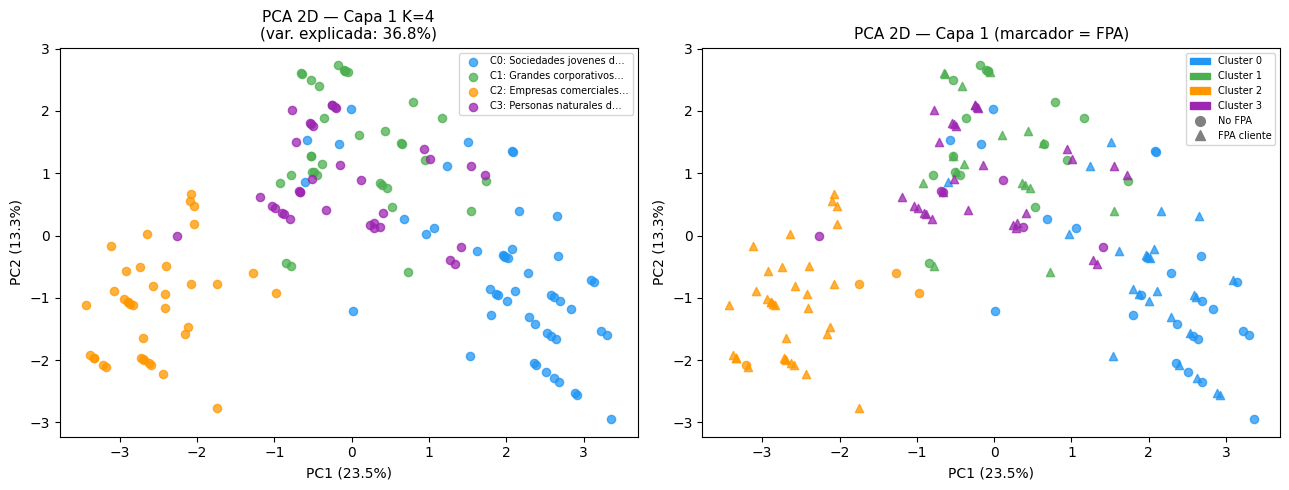

✓ Guardado: fig_pca_capa1.png


In [36]:
# ── PCA 2D — Capa 1 ──────────────────────────────────────────────────────────
pca_c1 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca_c1 = pca_c1.fit_transform(X_c1_scaled)
var_exp_c1 = pca_c1.explained_variance_ratio_
print(f"Capa 1 — Varianza explicada PC1+PC2: {var_exp_c1.sum():.1%}  (PC1={var_exp_c1[0]:.1%}, PC2={var_exp_c1[1]:.1%})")

fpa_c1_arr = clusters_c1.set_index("RUC").reindex(df_c1_dedup["RUC"])["es_cliente_fpa"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title_suffix in [(axes[0], "color=cluster"), (axes[1], "forma=FPA")]:
    for cl in range(4):
        mask = labels_c1 == cl
        nm   = perfil_c1.loc[perfil_c1["cluster_capa1"] == cl, "segmento_capa1"].values[0]
        if title_suffix == "color=cluster":
            ax.scatter(Z_pca_c1[mask, 0], Z_pca_c1[mask, 1],
                       c=PALETTE_C1[cl], s=35, alpha=0.75, label=f"C{cl}: {nm[:20]}…")
        else:
            markers = ["o" if fpa else "^" for fpa in fpa_c1_arr[mask]]
            for x, y, m in zip(Z_pca_c1[mask, 0], Z_pca_c1[mask, 1], markers):
                ax.scatter(x, y, c=PALETTE_C1[cl], s=35, alpha=0.75, marker=m)

ax0 = axes[0]
ax0.set_title(f"PCA 2D — Capa 1 K=4\n(var. explicada: {var_exp_c1.sum():.1%})", fontsize=11)
ax0.set_xlabel(f"PC1 ({var_exp_c1[0]:.1%})")
ax0.set_ylabel(f"PC2 ({var_exp_c1[1]:.1%})")
ax0.legend(fontsize=7, loc="best")

ax1 = axes[1]
ax1.set_title("PCA 2D — Capa 1 (marcador = FPA)", fontsize=11)
ax1.set_xlabel(f"PC1 ({var_exp_c1[0]:.1%})")
ax1.set_ylabel(f"PC2 ({var_exp_c1[1]:.1%})")
legend_patches = [
    mpatches.Patch(color=PALETTE_C1[i], label=f"Cluster {i}") for i in range(4)
] + [
    plt.Line2D([0], [0], marker="o", color="gray", label="No FPA", linestyle="None", markersize=7),
    plt.Line2D([0], [0], marker="^", color="gray", label="FPA cliente", linestyle="None", markersize=7),
]
ax1.legend(handles=legend_patches, fontsize=7, loc="best")

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_pca_capa1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_pca_capa1.png")

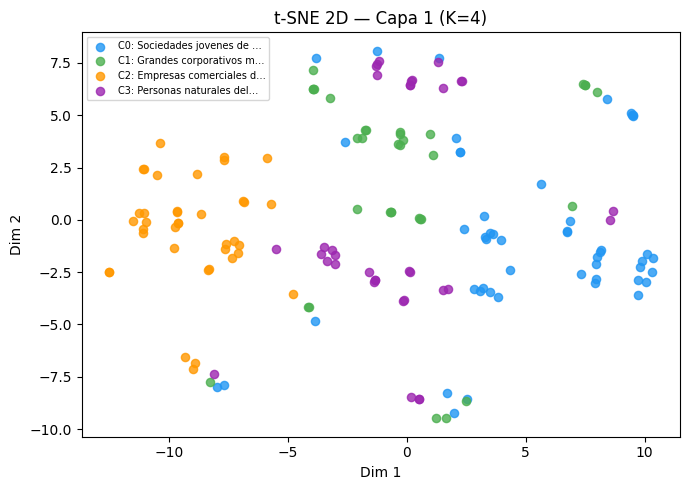

✓ Guardado: fig_tsne_capa1.png

Capa 2 — Varianza explicada PC1+PC2: 39.8%


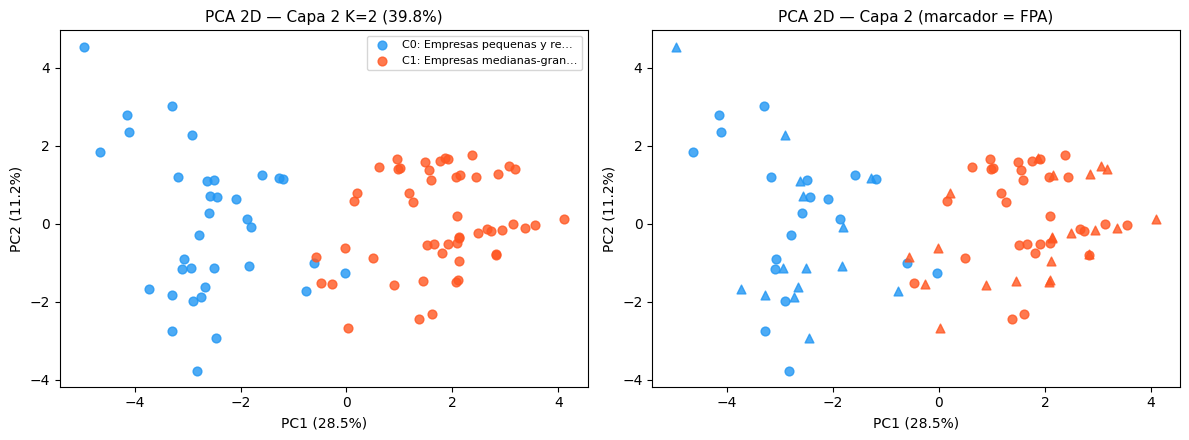

✓ Guardado: fig_pca_capa2.png


In [37]:
# ── t-SNE 2D — Capa 1 ────────────────────────────────────────────────────────
tsne_c1 = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
Z_tsne_c1 = tsne_c1.fit_transform(X_c1_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for cl in range(4):
    mask = labels_c1 == cl
    nm   = perfil_c1.loc[perfil_c1["cluster_capa1"] == cl, "segmento_capa1"].values[0]
    ax.scatter(Z_tsne_c1[mask, 0], Z_tsne_c1[mask, 1],
               c=PALETTE_C1[cl], s=35, alpha=0.8, label=f"C{cl}: {nm[:22]}…")
ax.set_title("t-SNE 2D — Capa 1 (K=4)", fontsize=12)
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_tsne_capa1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_tsne_capa1.png")

# ── PCA 2D — Capa 2 ──────────────────────────────────────────────────────────
pca_c2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca_c2 = pca_c2.fit_transform(X_c2_scaled)
var_exp_c2 = pca_c2.explained_variance_ratio_
fpa_c2_arr = clusters_c2.set_index("RUC").reindex(labels_c2_meta["RUC"])["es_cliente_fpa"].values
print(f"\nCapa 2 — Varianza explicada PC1+PC2: {var_exp_c2.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, title_suffix in [(axes[0], "cluster"), (axes[1], "FPA")]:
    for cl in range(2):
        mask = labels_c2 == cl
        nm   = perfil_c2.loc[perfil_c2["cluster_capa2"] == cl, "segmento_capa2"].values[0]
        if title_suffix == "cluster":
            ax.scatter(Z_pca_c2[mask, 0], Z_pca_c2[mask, 1],
                       c=PALETTE_C2[cl], s=40, alpha=0.8, label=f"C{cl}: {nm[:22]}…")
        else:
            for x, y, fpa in zip(Z_pca_c2[mask, 0], Z_pca_c2[mask, 1], fpa_c2_arr[mask]):
                ax.scatter(x, y, c=PALETTE_C2[cl], s=40, alpha=0.8,
                           marker="^" if fpa else "o")

axes[0].set_title(f"PCA 2D — Capa 2 K=2 ({var_exp_c2.sum():.1%})", fontsize=11)
axes[1].set_title("PCA 2D — Capa 2 (marcador = FPA)", fontsize=11)
for ax in axes:
    ax.set_xlabel(f"PC1 ({var_exp_c2[0]:.1%})"); ax.set_ylabel(f"PC2 ({var_exp_c2[1]:.1%})")
axes[0].legend(fontsize=8, loc="best")

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_pca_capa2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_pca_capa2.png")

## 7. Análisis de sesgo de cobertura financiera (SCVS)

=== Cobertura financiera por cluster de Capa 1 ===


,cluster_capa1,segmento_capa1,n_total,n_con_financieras,cobertura_financiera,tasa_clientes_fpa
0,0,Sociedades jovenes de alta afinidad FPA,50,41,0.8200,0.4800
1,1,Grandes corporativos maduros establecidos,34,22,0.6471,0.5000
2,2,Empresas comerciales de Guayas,38,0,0.0000,0.1053
3,3,Personas naturales del resto del pais,35,24,0.6857,0.1714



✓ Cluster(s) con cobertura SCVS = 0%: [2] — CONFIRMADO

Correlación Spearman (cobertura_SCVS ~ tasa_FPA): ρ=0.400  p=0.6000


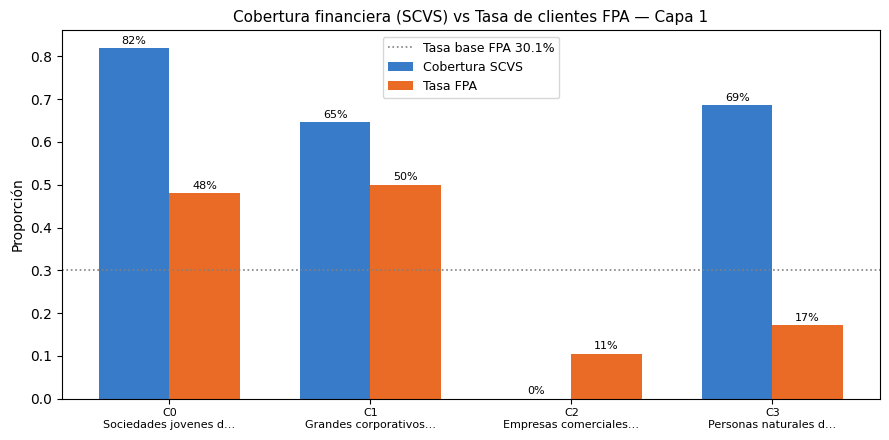

✓ Guardado: fig_cobertura_vs_fpa.png


In [38]:
# ── Cobertura SCVS por cluster de Capa 1 ─────────────────────────────────────
print("=== Cobertura financiera por cluster de Capa 1 ===")
display(cobertura_c1.round(4))

# Verificación dinámica: debe existir al menos un cluster con cobertura = 0
clusters_cob0 = cobertura_c1.loc[cobertura_c1["cobertura_financiera"] == 0.0, "cluster_capa1"].tolist()
assert len(clusters_cob0) >= 1, "Se esperaba al menos un cluster con cobertura SCVS = 0.0"
print(f"\n✓ Cluster(s) con cobertura SCVS = 0%: {clusters_cob0} — CONFIRMADO")

# ── Correlación Spearman: cobertura vs tasa FPA ───────────────────────────────
rho, p_rho = spearmanr(cobertura_c1["cobertura_financiera"], cobertura_c1["tasa_clientes_fpa"])
print(f"\nCorrelación Spearman (cobertura_SCVS ~ tasa_FPA): ρ={rho:.3f}  p={p_rho:.4f}")

# ── Gráfico: cobertura y tasa FPA por cluster ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(cobertura_c1))
width = 0.35
bars1 = ax.bar(x - width/2, cobertura_c1["cobertura_financiera"], width,
               label="Cobertura SCVS", color="#1565C0", alpha=0.85)
bars2 = ax.bar(x + width/2, cobertura_c1["tasa_clientes_fpa"], width,
               label="Tasa FPA", color="#E65100", alpha=0.85)

ax.set_xticks(x)
segs = [s[:20] + "…" for s in cobertura_c1["segmento_capa1"]]
ax.set_xticklabels([f"C{i}\n{s}" for i, s in zip(cobertura_c1["cluster_capa1"], segs)], fontsize=8)
ax.set_ylabel("Proporción")
ax.set_title("Cobertura financiera (SCVS) vs Tasa de clientes FPA — Capa 1", fontsize=11)
ax.axhline(TASA_BASE_C1, color="gray", linestyle=":", linewidth=1.2, label=f"Tasa base FPA {TASA_BASE_C1:.1%}")
ax.legend(fontsize=9)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.0%}", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(EVAL_OUT / "fig_cobertura_vs_fpa.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: fig_cobertura_vs_fpa.png")


## 8. Análisis de sensibilidad Capa 2 con K=4 y efecto outliers

In [39]:
# ── Comparación K=2 vs K=4 en Capa 2 ─────────────────────────────────────────
print("=== Perfil Capa 2 K=2 (solución robusta) ===")
display(perfil_c2[["cluster_capa2", "segmento_capa2", "n", "tasa_clientes_fpa"]].round(3))

print("\n=== Perfil Capa 2 K=4 (análisis de sensibilidad) ===")
display(perfil_c2_k4[["cluster_capa2_k4", "n", "tasa_clientes_fpa",
                       "mediana_antiguedad_anos", "mediana_log_ingresos"]].round(3))

# ── Comparación de métricas K=2 vs K=4 ───────────────────────────────────────
sil_k2 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 2, "silhouette"].values[0]
db_k2  = met_kmeans_c2.loc[met_kmeans_c2["k"] == 2, "davies_bouldin"].values[0]
sil_k4 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "silhouette"].values[0]
db_k4  = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "davies_bouldin"].values[0]
min_k4 = met_kmeans_c2.loc[met_kmeans_c2["k"] == 4, "min_cluster_size"].values[0]

print(f"\nMétricas Capa 2 K=2: Sil={sil_k2:.3f}  DB={db_k2:.3f}  min_cluster=35+")
print(f"Métricas Capa 2 K=4: Sil={sil_k4:.3f}  DB={db_k4:.3f}  min_cluster={min_k4}")
print("\n→ K=4 mejora Sil y DB pero produce micro-clusters de 1-2 empresas (outliers)")
print("→ K=2 es la solución robusta preferida para análisis gerencial")

# ── Identificación de outliers en K=4 ────────────────────────────────────────
outliers = clusters_c2_k4[clusters_c2_k4.groupby("cluster_capa2_k4")["cluster_capa2_k4"]
                           .transform("count") <= 2]
if len(outliers) > 0:
    print(f"\nOutliers (clusters con ≤2 empresas en K=4): {len(outliers)} empresa(s)")
    display(outliers[["RUC", "cluster_capa2_k4"]].head(10))
else:
    print("\nNo se detectaron micro-clusters de ≤2 empresas en K=4 de Capa 2")

=== Perfil Capa 2 K=2 (solución robusta) ===


,cluster_capa2,segmento_capa2,n,tasa_clientes_fpa
0,0,Empresas pequenas y recientes,35,0.429
1,1,Empresas medianas-grandes consolidadas,52,0.423



=== Perfil Capa 2 K=4 (análisis de sensibilidad) ===


,cluster_capa2_k4,n,tasa_clientes_fpa,mediana_antiguedad_anos,mediana_log_ingresos
0,0,34,0.412,8.0,0.00
1,1,50,0.440,36.5,7.54
2,2,2,0.500,9.5,2.36
3,3,1,0.000,30.0,7.37



Métricas Capa 2 K=2: Sil=0.386  DB=1.093  min_cluster=35+
Métricas Capa 2 K=4: Sil=0.409  DB=0.688  min_cluster=1

→ K=4 mejora Sil y DB pero produce micro-clusters de 1-2 empresas (outliers)
→ K=2 es la solución robusta preferida para análisis gerencial

Outliers (clusters con ≤2 empresas en K=4): 3 empresa(s)


,RUC,cluster_capa2_k4
12,1791324404001,3
33,1792333881001,2
86,2490398352001,2


## 9. Exportación de métricas y artefactos de evaluación

In [40]:
# ── Tabla de métricas de evaluación final ─────────────────────────────────────
metricas_eval_c1 = pd.DataFrame({
    "capa":         ["Capa1"] * len(met_kmeans_c1),
    "metodo":       ["KMeans"] * len(met_kmeans_c1),
    **met_kmeans_c1.to_dict("list"),
})
metricas_eval_c1_ward = pd.DataFrame({
    "capa":         ["Capa1"] * len(met_ward_c1),
    "metodo":       ["Ward"] * len(met_ward_c1),
    **met_ward_c1.to_dict("list"),
})
metricas_eval_c2 = pd.DataFrame({
    "capa":         ["Capa2"] * len(met_kmeans_c2),
    "metodo":       ["KMeans"] * len(met_kmeans_c2),
    **met_kmeans_c2.to_dict("list"),
})

# Tabla ARI
tabla_ari = pd.DataFrame({
    "comparacion":    ["C1_K4_vs_C2_K2 (mejor K)", "C1_K4_vs_C2_K4 (misma granularidad)"],
    "n_empresas_comunes": [len(comun), len(comun_k4)],
    "ARI":            [ari_best, ari_same],
})

# Validación externa
val_c1_export = val_c1.copy()
val_c2_export = val_c2.copy()

# ── Guardar CSVs ──────────────────────────────────────────────────────────────
metricas_eval_c1.to_csv(EVAL_OUT / "metricas_evaluacion_capa1.csv",       index=False)
metricas_eval_c1_ward.to_csv(EVAL_OUT / "metricas_evaluacion_capa1_ward.csv", index=False)
metricas_eval_c2.to_csv(EVAL_OUT / "metricas_evaluacion_capa2.csv",       index=False)
tabla_ari.to_csv(EVAL_OUT / "tabla_concordancia_ari.csv",                  index=False)
val_c1_export.to_csv(EVAL_OUT / "validacion_externa_capa1.csv",            index=False)
val_c2_export.to_csv(EVAL_OUT / "validacion_externa_capa2.csv",            index=False)
cobertura_c1.to_csv(EVAL_OUT / "cobertura_financiera_por_cluster.csv",     index=False)

print("✓ CSVs exportados en 05_evaluation/outputs/:")
for f in sorted(EVAL_OUT.glob("*.csv")):
    print(f"   {f.name}")
print()
for f in sorted(EVAL_OUT.glob("*.png")):
    print(f"   {f.name}")

✓ CSVs exportados en 05_evaluation/outputs/:
   cobertura_financiera_por_cluster.csv
   metricas_evaluacion_capa1.csv
   metricas_evaluacion_capa1_ward.csv
   metricas_evaluacion_capa2.csv
   tabla_concordancia_ari.csv
   validacion_externa_capa1.csv
   validacion_externa_capa2.csv

   fig_cobertura_vs_fpa.png
   fig_pca_capa1.png
   fig_pca_capa2.png
   fig_seleccion_k_kmeans.png
   fig_silhouette_muestras_c1.png
   fig_tasa_fpa_por_cluster.png
   fig_tsne_capa1.png


In [41]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN DE EVALUACIÓN DEL MODELO DE CLUSTERING — FPA Latam")
print("=" * 60)
print(f"\n{'CAPA 1 (SRI, N=163, K=4)'}")
print(f"  Silhouette (KMeans K=4) : {sil_c1:.3f}")
print(f"  Davies-Bouldin (K=4)   : {db_c1:.3f}")
print(f"  Tasa FPA global        : {TASA_BASE_C1:.1%}")
print(f"  Chi-cuadrado vs FPA    : χ²={chi2_c1:.2f}  p={p_c1:.4f}")
for _, row in val_c1.iterrows():
    flag = "↑" if row["tasa_clientes"] > TASA_BASE_C1 else "↓"
    seg  = str(row.get("segmento", row.get("segmento_capa1", "—")))
    print(f"    C{int(row['cluster_capa1'])}: {seg[:32]:<32s}  {row['tasa_clientes']:.1%} {flag}")

print(f"\n{'CAPA 2 (SRI+SCVS, N=92, K=2)'}")
print(f"  Silhouette (KMeans K=2) : {sil_c2:.3f}")
print(f"  Davies-Bouldin (K=2)   : {db_c2:.3f}")
print(f"  Tasa FPA global        : {TASA_BASE_C2:.1%}")
print(f"  Chi-cuadrado vs FPA    : χ²={chi2_c2:.2f}  p={p_c2:.4f}")
for _, row in val_c2.iterrows():
    flag = "↑" if row["tasa_clientes"] > TASA_BASE_C2 else "↓"
    seg  = str(row.get("segmento", row.get("segmento_capa2", "—")))
    print(f"    C{int(row['cluster_capa2'])}: {seg[:32]:<32s}  {row['tasa_clientes']:.1%} {flag}")

print(f"\n{'CONCORDANCIA ENTRE CAPAS'}")
print(f"  ARI Capa1-K4 vs Capa2-K2 : {ari_best:.3f}  (concordancia moderada)")
print(f"  ARI Capa1-K4 vs Capa2-K4 : {ari_same:.3f}  (mayor granularidad)")

print(f"\n{'COBERTURA SCVS POR CLUSTER CAPA 1'}")
for _, row in cobertura_c1.iterrows():
    print(f"  C{int(row['cluster_capa1'])}: {row['cobertura_financiera']:.1%} cobertura")

print("\n" + "=" * 60)
print("Archivos exportados en 05_evaluation/outputs/")
print(f"  CSVs : {len(list(EVAL_OUT.glob('*.csv')))}")
print(f"  PNGs : {len(list(EVAL_OUT.glob('*.png')))}")
print("=" * 60)

RESUMEN DE EVALUACIÓN DEL MODELO DE CLUSTERING — FPA Latam

CAPA 1 (SRI, N=163, K=4)
  Silhouette (KMeans K=4) : 0.170
  Davies-Bouldin (K=4)   : 1.853
  Tasa FPA global        : 30.1%
  Chi-cuadrado vs FPA    : χ²=22.35  p=0.0001
    C0: Sociedades jovenes de alta afini  48.0% ↑
    C1: Grandes corporativos maduros est  50.0% ↑
    C2: Empresas comerciales de Guayas    10.5% ↓
    C3: Personas naturales del resto del  17.1% ↓

CAPA 2 (SRI+SCVS, N=92, K=2)
  Silhouette (KMeans K=2) : 0.249
  Davies-Bouldin (K=2)   : 1.680
  Tasa FPA global        : 39.1%
  Chi-cuadrado vs FPA    : χ²=0.00  p=1.0000
    C0: Empresas pequenas y recientes     42.9% ↑
    C1: Empresas medianas-grandes consol  42.3% ↑

CONCORDANCIA ENTRE CAPAS
  ARI Capa1-K4 vs Capa2-K2 : 0.376  (concordancia moderada)
  ARI Capa1-K4 vs Capa2-K4 : 0.324  (mayor granularidad)

COBERTURA SCVS POR CLUSTER CAPA 1
  C0: 82.0% cobertura
  C1: 64.7% cobertura
  C2: 0.0% cobertura
  C3: 68.6% cobertura

Archivos exportados en 05_ev